In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars
##############################################################

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_
##############################################################

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
##############################################################
                    
def setrandomcontrol(control_, max_cntrl_, min_cntrl_, cntrl_vars_):
    for n in range(control_.shape[0]):
        for v in range(control_.shape[1]):
            if v in cntrl_vars_:
                mean_cntrl = np.mean( [max_cntrl_[v], min_cntrl_[v]] )
                control_[n,v,1] = mean_cntrl
                for t in range(2, control_.shape[2]-1):
                    control_[n,v,t] = control_[n,v,t-1] + 0.01 * mean_cntrl * random.uniform(-1, 1)
                    
    return control_
##############################################################
                    
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl    

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

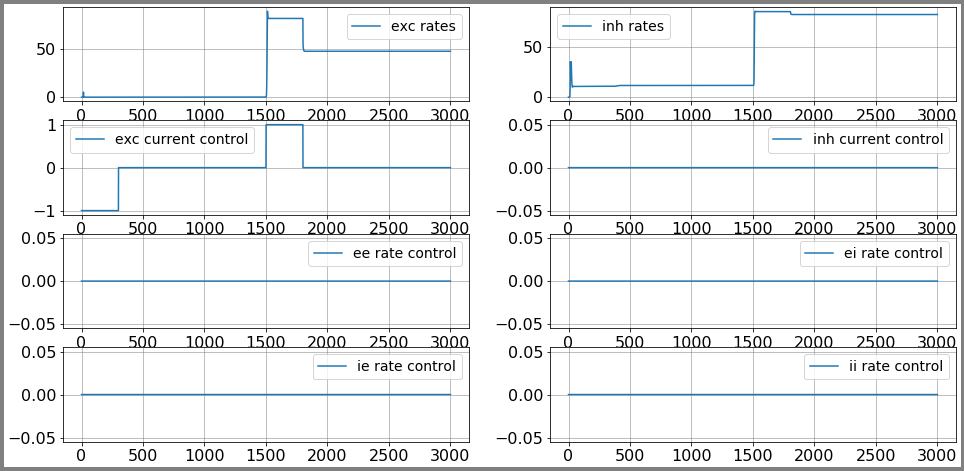

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


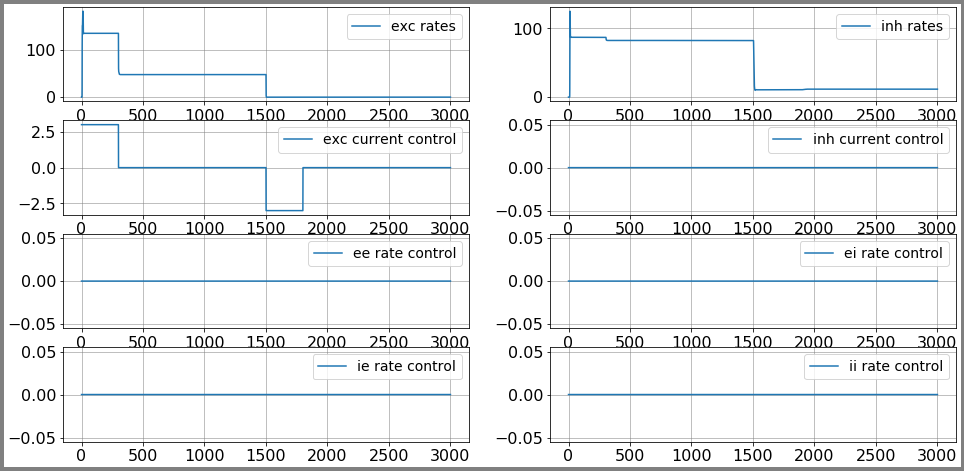

In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]
        
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]


In [4]:
# 8 cases
# ee, ei, ie, ii
c_var = [ [0], [1], [0,1], [2], [3], [4], [5], [2,3,4,5] ]
p_var = [ [0], [0], [0], [0], [0], [0], [0], [0] ]

bestControla = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
bestStatea = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
costa = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
runtimea = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
grada = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
phia= [ [], [], [], [], [], [], [], [], [], [], [], [] ]

bestControlb = [ [], [], [], [], [], [], [], [], [], [], [], []]
bestStateb = [ [], [], [], [], [], [], [], [], [], [], [], [] ]
costb = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
runtimeb = [ 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0. ]
gradb = [ [], [], [], [], [], [], [], [], [], [], [], []]
phib= [ [], [], [], [], [], [], [], [], [], [], [], []]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

trans_time_array = np.zeros(( len(c_var) ))
trans_time_array[:] = 0.8

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])
initVars = low_state_vars

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

sheet = "state_switching"
max_it = 1000

### Cases

Numer | Input | Input label | Result
---------|--------------|-----------|-----------
1 | E current | 0 | 0
2 | I current | 1 | 0
3 | E + I current | 0,1 | 0
4 | EE rate | 2 | 0
5 | EI rate | 3 | 0
6 | IE rate | 4 | 0
7 | II rate | 5 | 0
8 | EE + EI + IE + II rate | 2,3,4,5 | 0

## 1

In [ ]:
c_ = 0
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(control0,
    target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  100.56627944793154
Gradient descend method:  None
RUN  1 , total integrated cost =  100.56627944792376
RUN  2 , total integrated cost =  100.56627944791343
RUN  3 , total integrated cost =  100.56627944789543
RUN  4 , total integrated cost =  100.56627944786442
RUN  5 , total integrated cost =  100.5662794477887
RUN  6 , total integrated cost =  100.5662794474901
RUN  7 , total integrated cost =  100.56627944514659
RUN  8 , total integrated cost =  100.56627923940216
RUN  9 , total integrated cost =  100.56627861223939
RUN  10 , total integrated cost =  100.5662786043243
RUN  11 , total integrated cost =  100.56627860368903
RUN  12 , total integrated cost =  100.56627860354024
RUN  13 , total integrated cost =  100.56627860348783
RUN  14 , total integrated cost =  100.566278603464
RUN  15 , total integrated cost =  100.5662786034521
RUN  16 , total integ

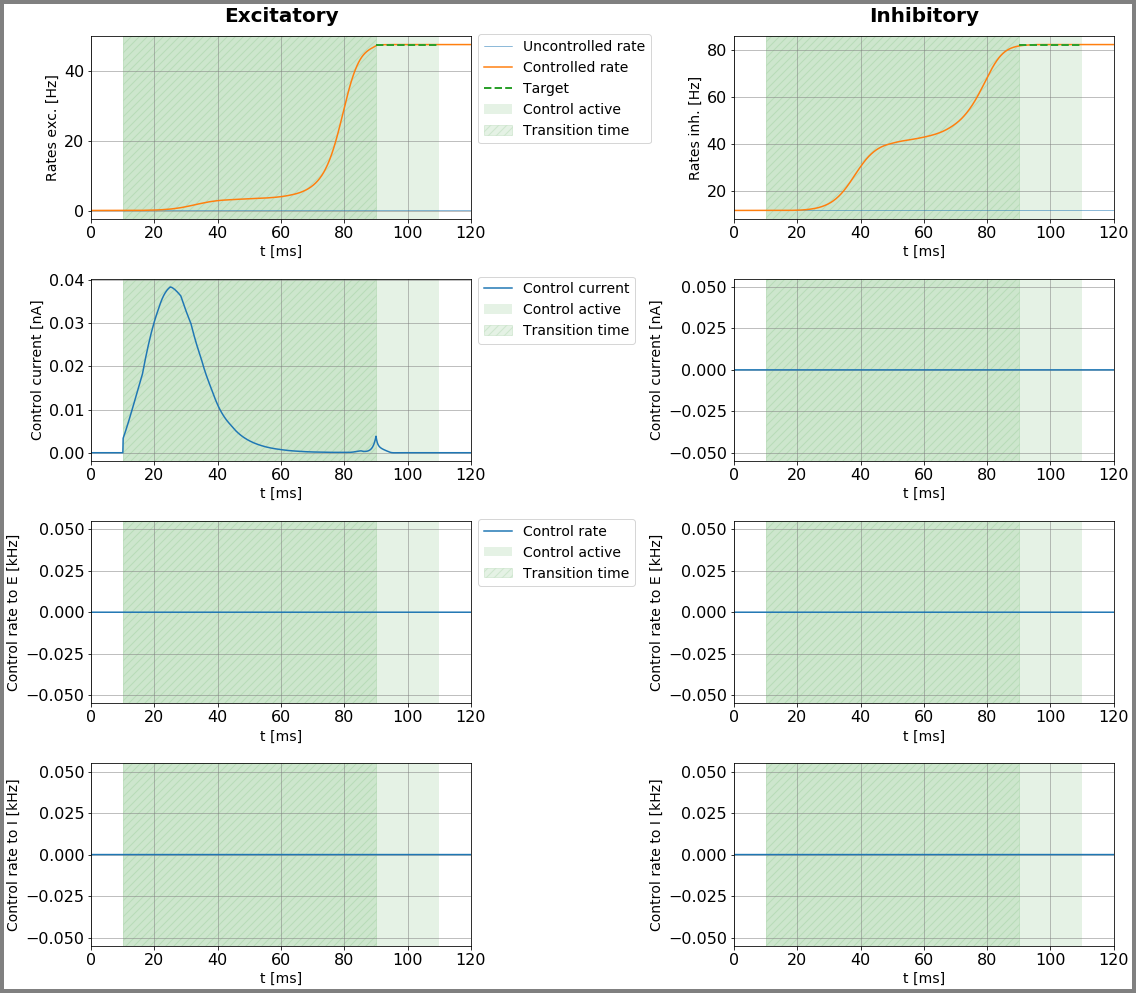

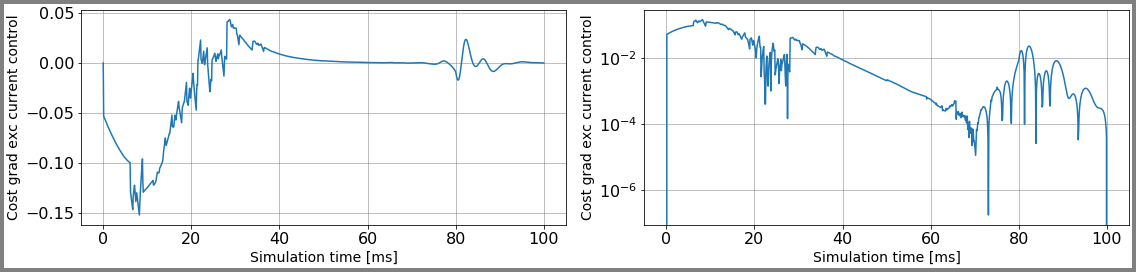

In [13]:
c_ = 0
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]
control2 = bestControlb[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control2, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 2

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  3859.672296503376
RUN  2 , total integrated cost =  88.30540409162167
RUN  3 , total integrated cost =  1.2412311560575862
RUN  4 , total integrated cost =  0.0598230614877892
RUN  5 , total integrated cost =  0.029961637979352862
RUN  6 , total integrated cost =  0.002949038737146899
RUN  7 , total integrated cost =  0.0015037102635284587
RUN  8 , total integrated cost =  0.0011131193937577847
RUN  9 , total integrated cost =  0.0008873623634675265
RUN  10 , total integrated cost =  0.0007342924806327018
RUN  11 , total integrated cost =  0.0006198705246234058
RUN  12 , total integrated cost =  0.000528319977673254
RUN  13 , total integrated cost =  0.00045085164027131844
RUN  14 , total integrated cost =  0.00038826517153170214
RUN  15 , total integrated cost =  0.00033

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  8.326046583743515e-08
RUN  1000 , total integrated cost =  8.326046583743515e-08
Improved over  1000  iterations in  30.234307599999966  seconds by  99.99999999962985  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459399763963 -56.174597782292906


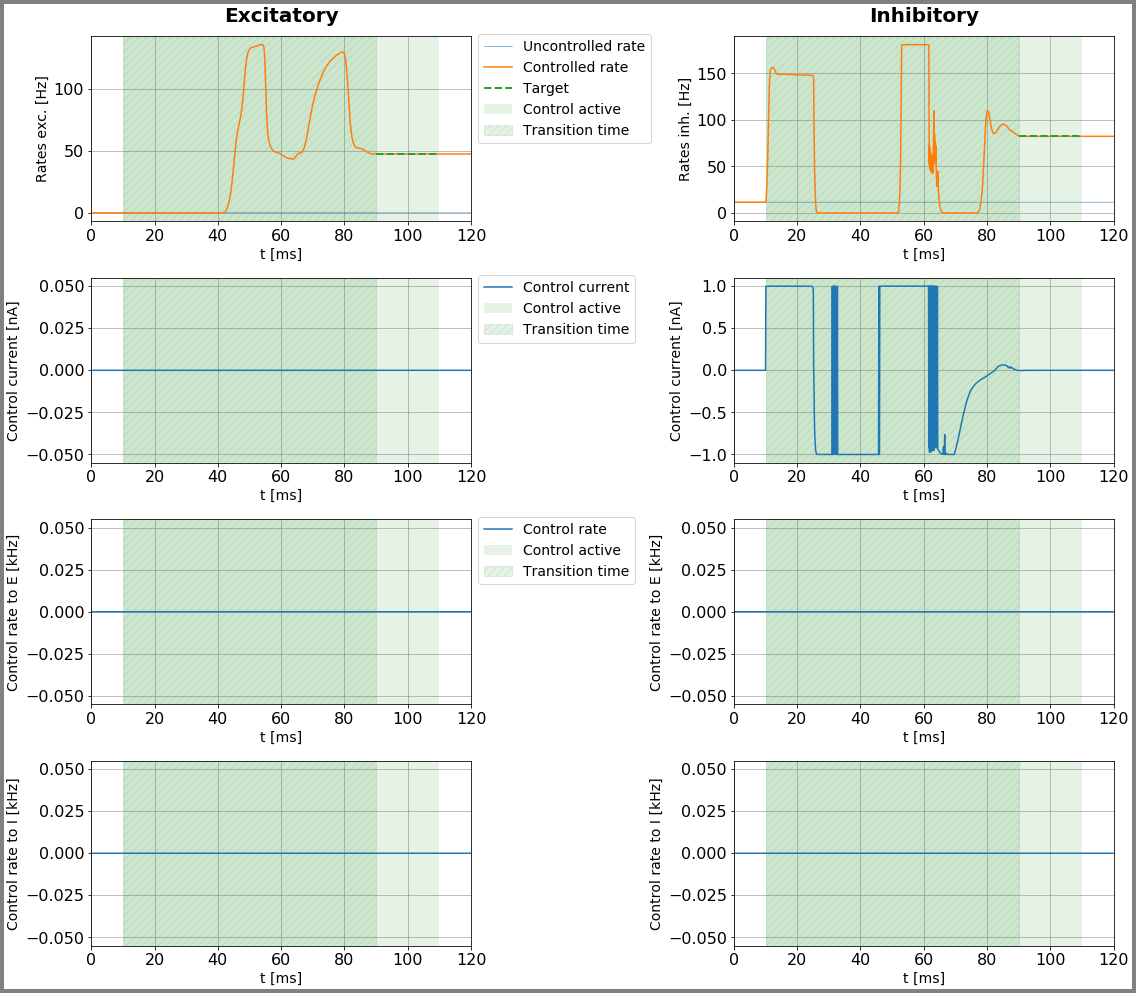

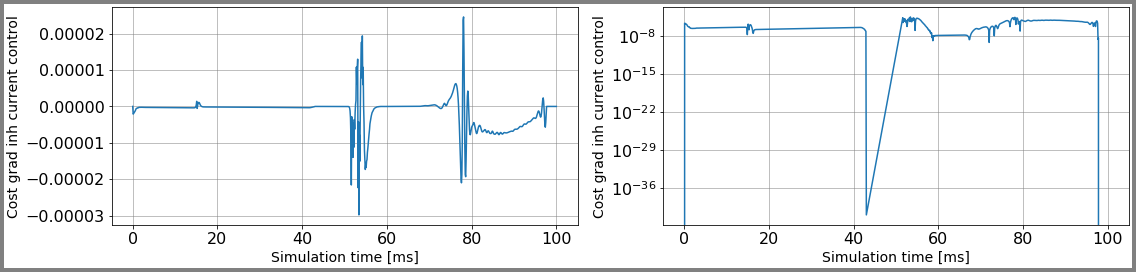

In [14]:
c_ = 1
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  80178.15527629462
Gradient descend method:  None
RUN  1 , total integrated cost =  368.9775719681506
RUN  2 , total integrated cost =  174.15836006476118
RUN  3 , total integrated cost =  140.1244105938733
RUN  4 , total integrated cost =  139.7942258582168
RUN  5 , total integrated cost =  136.6791393539059
RUN  6 , total integrated cost =  95.89241420936607
RUN  7 , total integrated cost =  94.08854780701965
RUN  8 , total integrated cost =  94.03425881785557
RUN  9 , total integrated cost =  93.93516036993815
RUN  10 , total integrated cost =  93.89583345435706
RUN  11 , total integrated cost =  93.80417027856821
RUN  12 , total integrated cost =  93.76605327233067
RUN  13 , total integrated cost =  93.68647971754645
RUN  14 , total integrated cost =  93.65295251767898
RUN  15 , total integrated cost =  93.58109090922791
RUN  16 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  49.91878128543388
RUN  1000 , total integrated cost =  49.91878128543388
Improved over  1000  iterations in  25.761592000000007  seconds by  99.93774017235316  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459044255673 -56.174590472455236


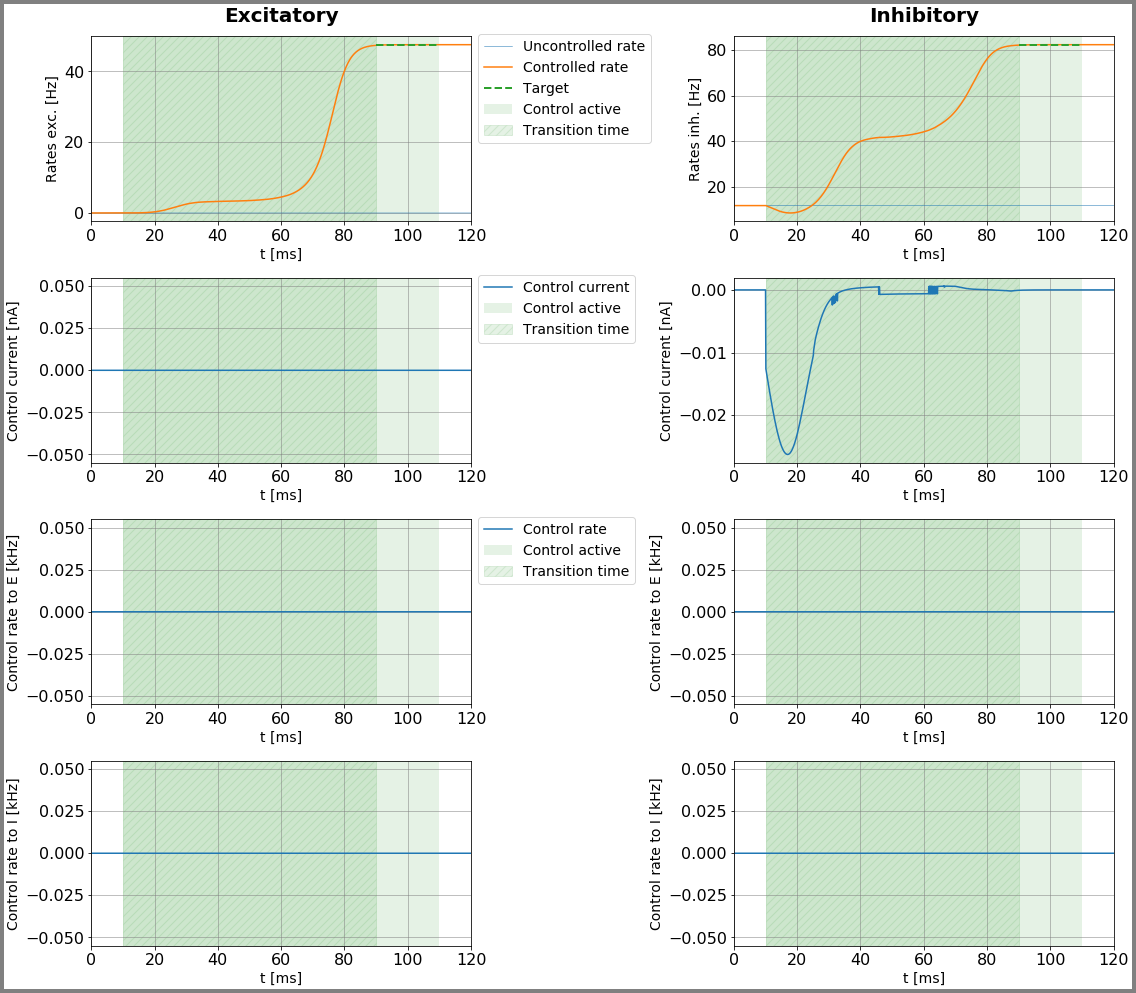

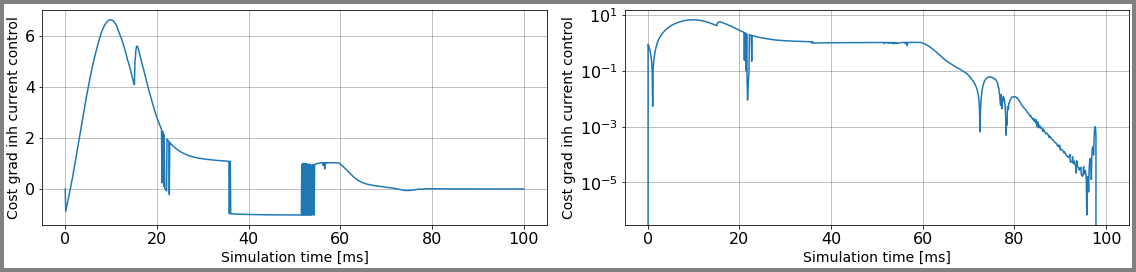

In [8]:
c_ = 1
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 3

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.494361608944
Gradient descend method:  None
RUN  1 , total integrated cost =  2949.072608149174
RUN  2 , total integrated cost =  1727.5249571588436
RUN  3 , total integrated cost =  537.9247471416692
RUN  4 , total integrated cost =  310.94839325314246
RUN  5 , total integrated cost =  199.0846206850091
RUN  6 , total integrated cost =  132.08026047641465
RUN  7 , total integrated cost =  89.81125768788664
RUN  8 , total integrated cost =  64.6722086266404
RUN  9 , total integrated cost =  47.648911482440894
RUN  10 , total integrated cost =  36.7603536670014
RUN  11 , total integrated cost =  29.258933102448715
RUN  12 , total integrated cost =  23.906448836445445
RUN  13 , total integrated cost =  20.032118726877286
RUN  14 , total integrated cost =  17.095538808581622
RUN  15 , total integrated cost =  14.780863171054927
RUN  16 , total inte

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.00046238711798886074
RUN  1000 , total integrated cost =  0.00046238711798886074
Improved over  1000  iterations in  48.00866289999999  seconds by  99.99999794435178  percent.
Problem in initial value trasfer:  Vmean_exc -56.174590026845394 -56.174585427317744


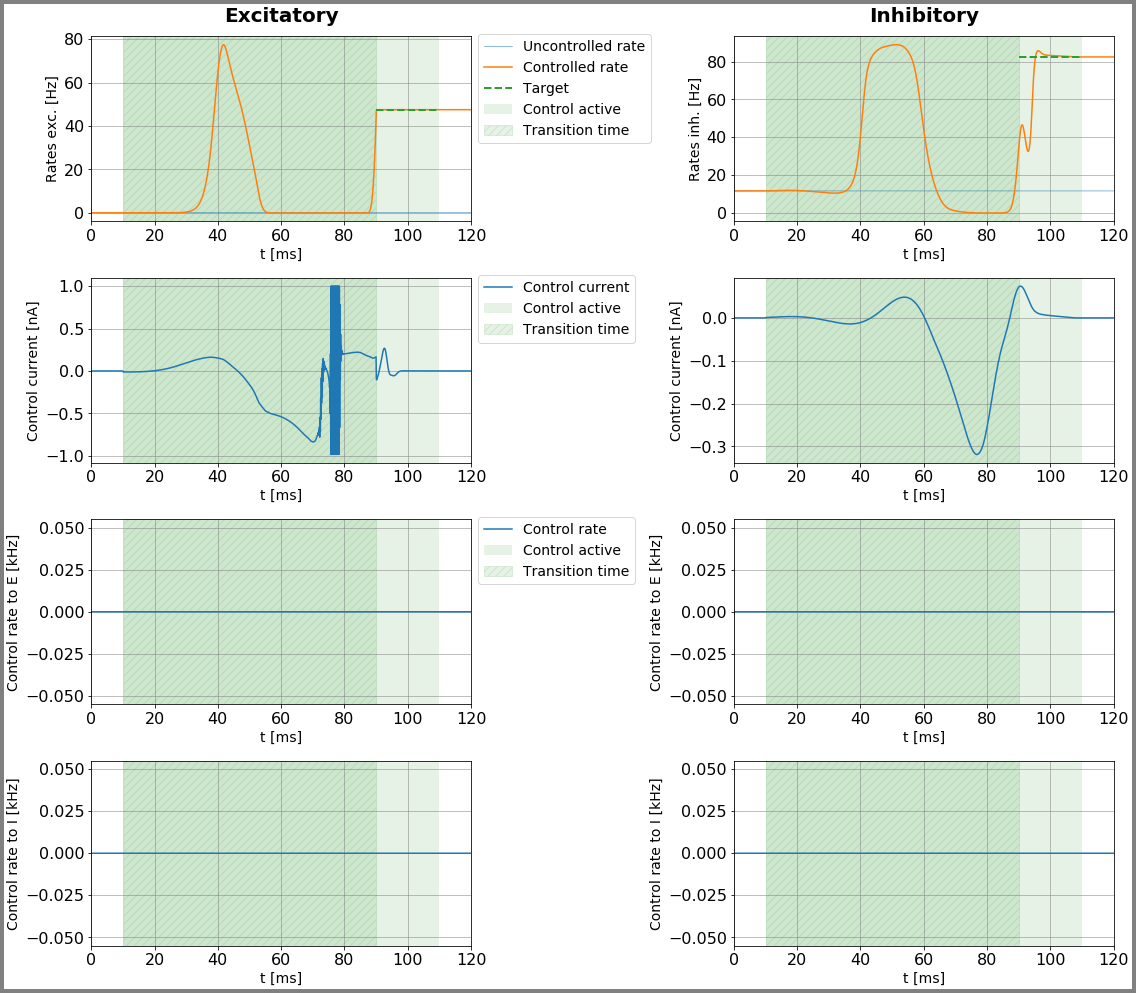

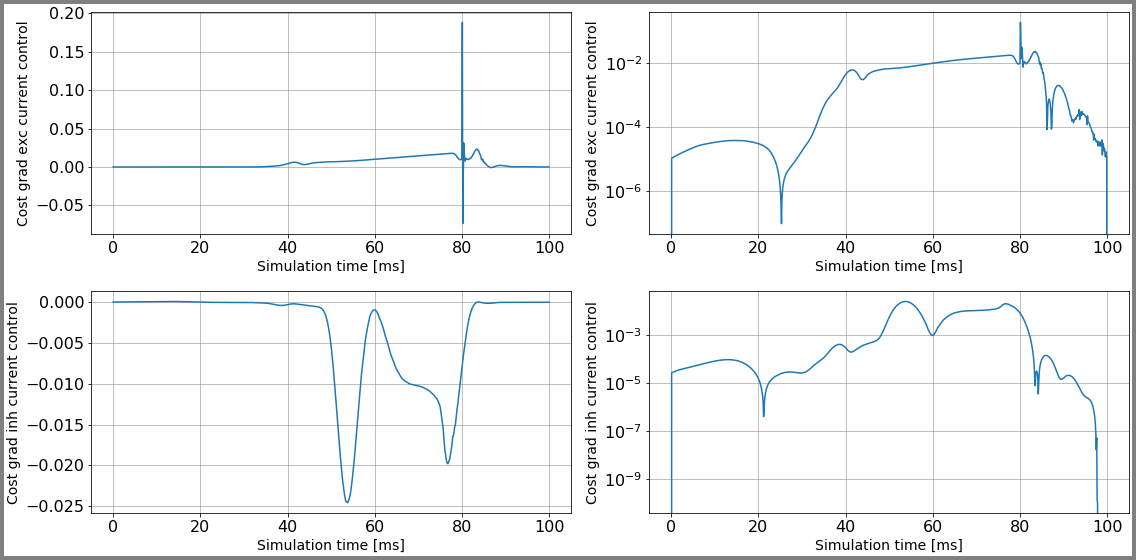

In [9]:
c_ = 2
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [0, 1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18328.204554534866
Gradient descend method:  None
RUN  1 , total integrated cost =  1773.4001372357666
RUN  2 , total integrated cost =  164.66429637358533
RUN  3 , total integrated cost =  138.95511046677933
RUN  4 , total integrated cost =  131.00461861672602
RUN  5 , total integrated cost =  127.2948774775995
RUN  6 , total integrated cost =  124.93286271237295
RUN  7 , total integrated cost =  122.18077117644214
RUN  8 , total integrated cost =  120.27162948694189
RUN  9 , total integrated cost =  117.96510972418496
RUN  10 , total integrated cost =  116.22059426706801
RUN  11 , total integrated cost =  114.1200219462789
RUN  12 , total integrated cost =  112.53413243500728
RUN  13 , total integrated cost =  110.60381640856716
RUN  14 , total integrated cost =  109.16079913264373
RUN  15 , total integrated cost =  107.37560964517426
RUN  16 , tota

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  50.10128848105211
RUN  1000 , total integrated cost =  50.10128848105211
Improved over  1000  iterations in  79.38608479999999  seconds by  99.72664377281485  percent.
Problem in initial value trasfer:  Vmean_exc -56.174588306788344 -56.174588421309835


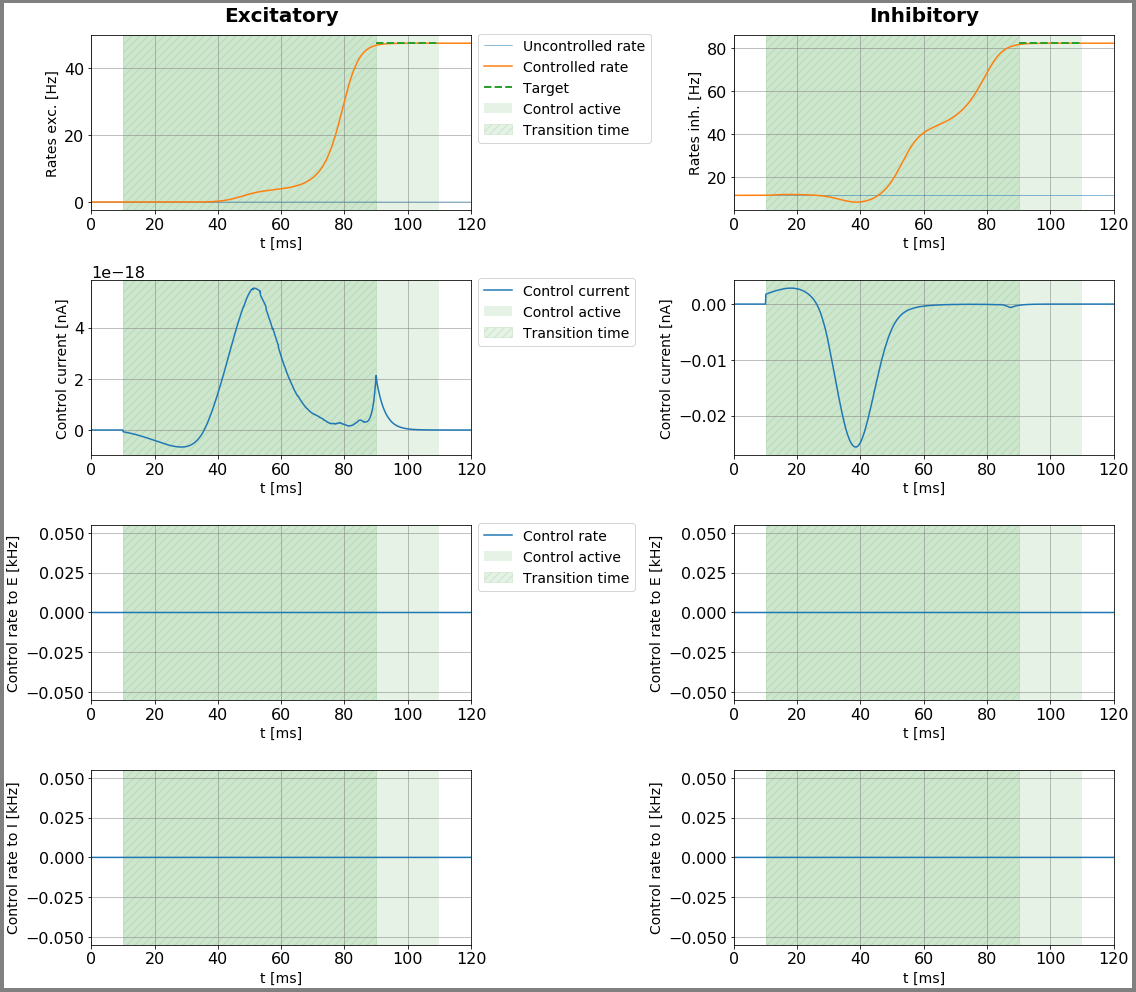

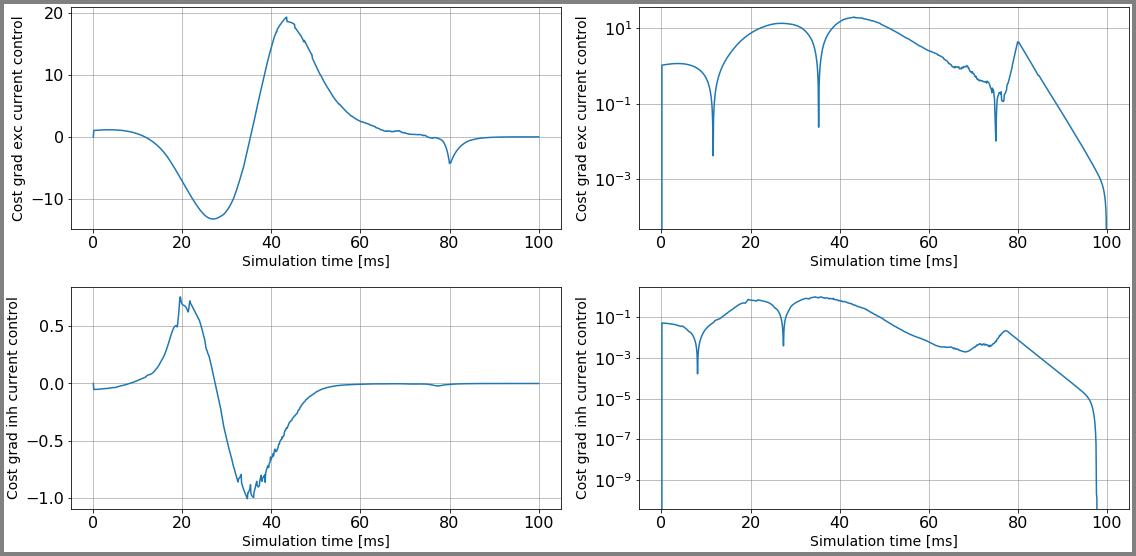

In [10]:
c_ = 2
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 4

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  100.93519001160928
Gradient descend method:  None
RUN  1 , total integrated cost =  0.013831322655499356
RUN  2 , total integrated cost =  6.833030746625315e-06
RUN  3 , total integrated cost =  3.0449488264903466e-08
RUN  4 , total integrated cost =  2.684398308043974e-11
RUN  5 , total integrated cost =  1.8803658421493756e-14
RUN  6 , total integrated cost =  1.7627001768536062e-17
RUN  7 , total integrated cost =  8.95290515506141e-21
RUN  8 , total integrated cost =  8.952619978688735e-21
RUN  9 , total integrated cost =  4.259962736599308e-22
RUN  10 , total integrated cost =  1.3363250470555609e-22
RUN  11 , total integrated cost =  9.700741701053908e-23
RUN  12 , total integrated cost =  7.471590671983882e-23
RUN  13 , total integrated cost =  4.7079935740380676e-23
RUN  14 , total integrated cost =  9.46633086265218e-26
RUN  15 , total integrate

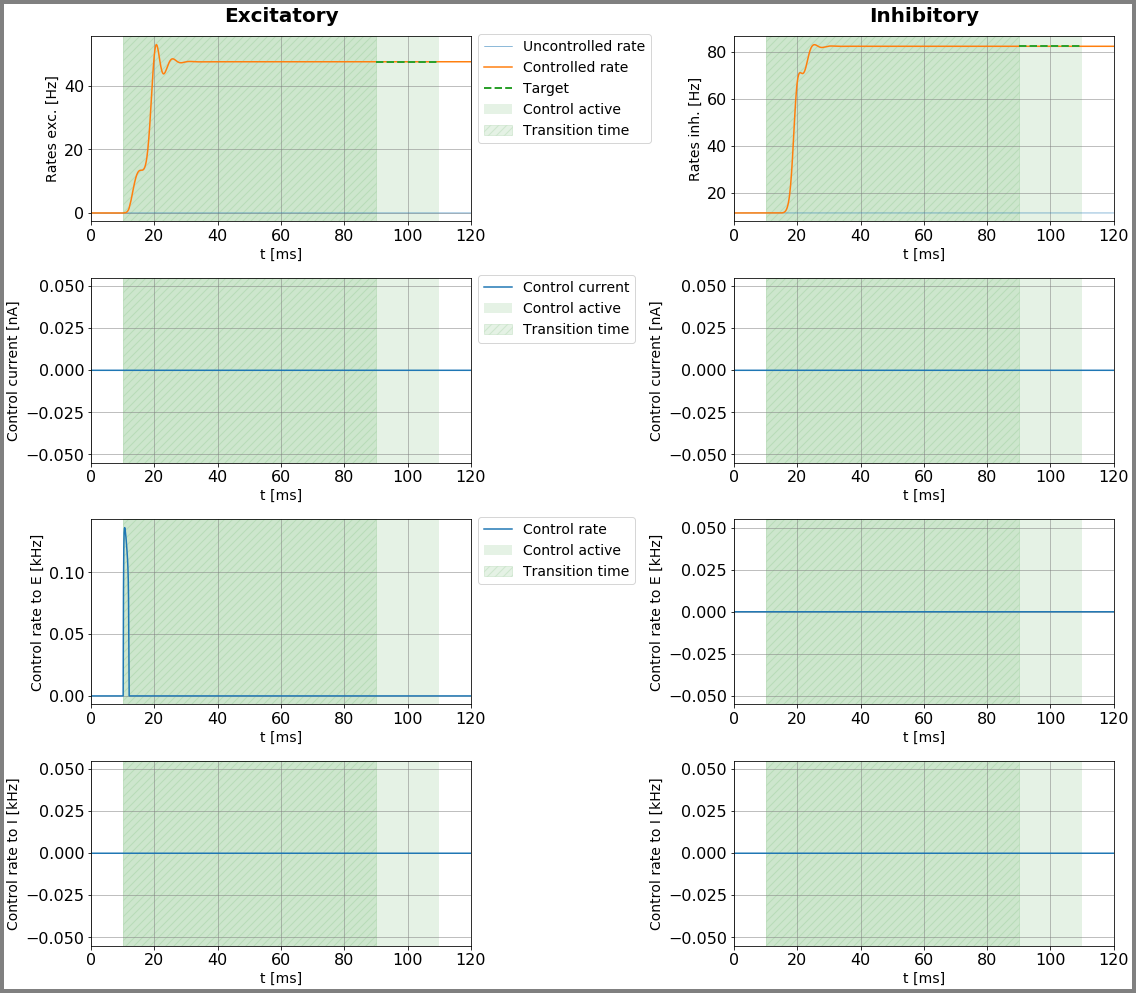

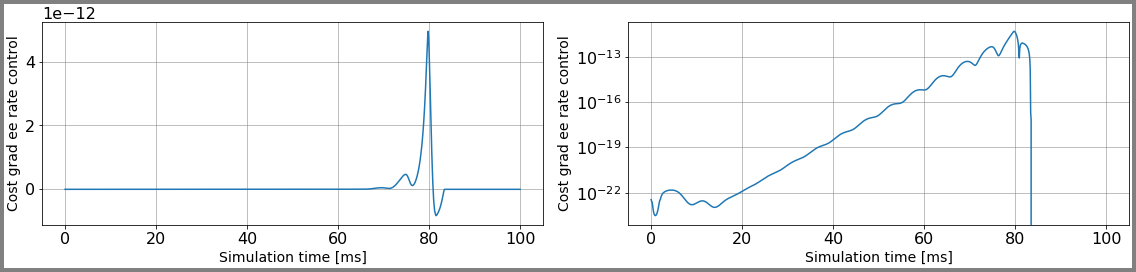

In [11]:
c_ = 3
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.789800449606584
Gradient descend method:  None
RUN  1 , total integrated cost =  2.197211143784531
RUN  2 , total integrated cost =  1.7600738076034168
RUN  3 , total integrated cost =  1.745872545567786
RUN  4 , total integrated cost =  1.7453523617072995
RUN  5 , total integrated cost =  1.7433806613309344
RUN  6 , total integrated cost =  1.7427715879122219
RUN  7 , total integrated cost =  1.7406639302895688
RUN  8 , total integrated cost =  1.7399729308740755
RUN  9 , total integrated cost =  1.7376139397697643
RUN  10 , total integrated cost =  1.7369187169547726
RUN  11 , total integrated cost =  1.7346131259709536
RUN  12 , total integrated cost =  1.7338720853831249
RUN  13 , total integrated cost =  1.7314887747648817
RUN  14 , total integrated cost =  1.7308196047970636
RUN  15 , total integrated cost =  1.7286676109100123
RUN  16 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.6105695995504763
RUN  1000 , total integrated cost =  0.6105695995504763
Improved over  1000  iterations in  25.20760150000001  seconds by  96.3634493370957  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.714245851427921
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.113466797626224


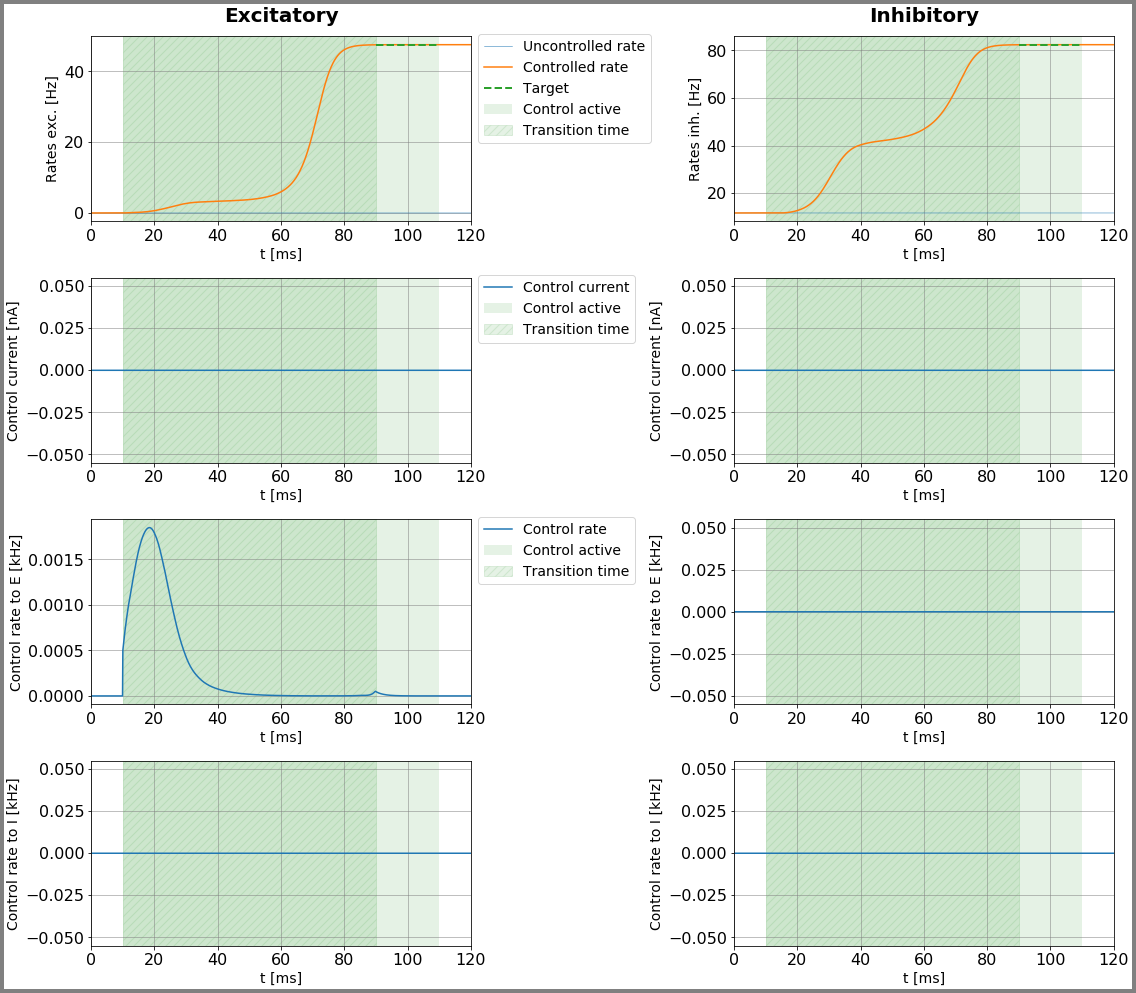

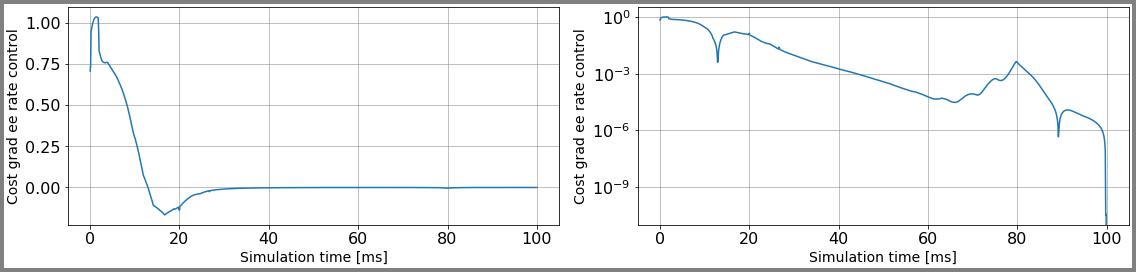

In [12]:
c_ = 3
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 5

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.017269299999952636  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 0.5046651299266925 0.5169635467535498
Problem in initial value trasfer:  Vmean_exc -74.01290330479063 -74.01500390646521
Problem in initial value trasfer:  tau_exc 27.00117093687824 26.930674690739245


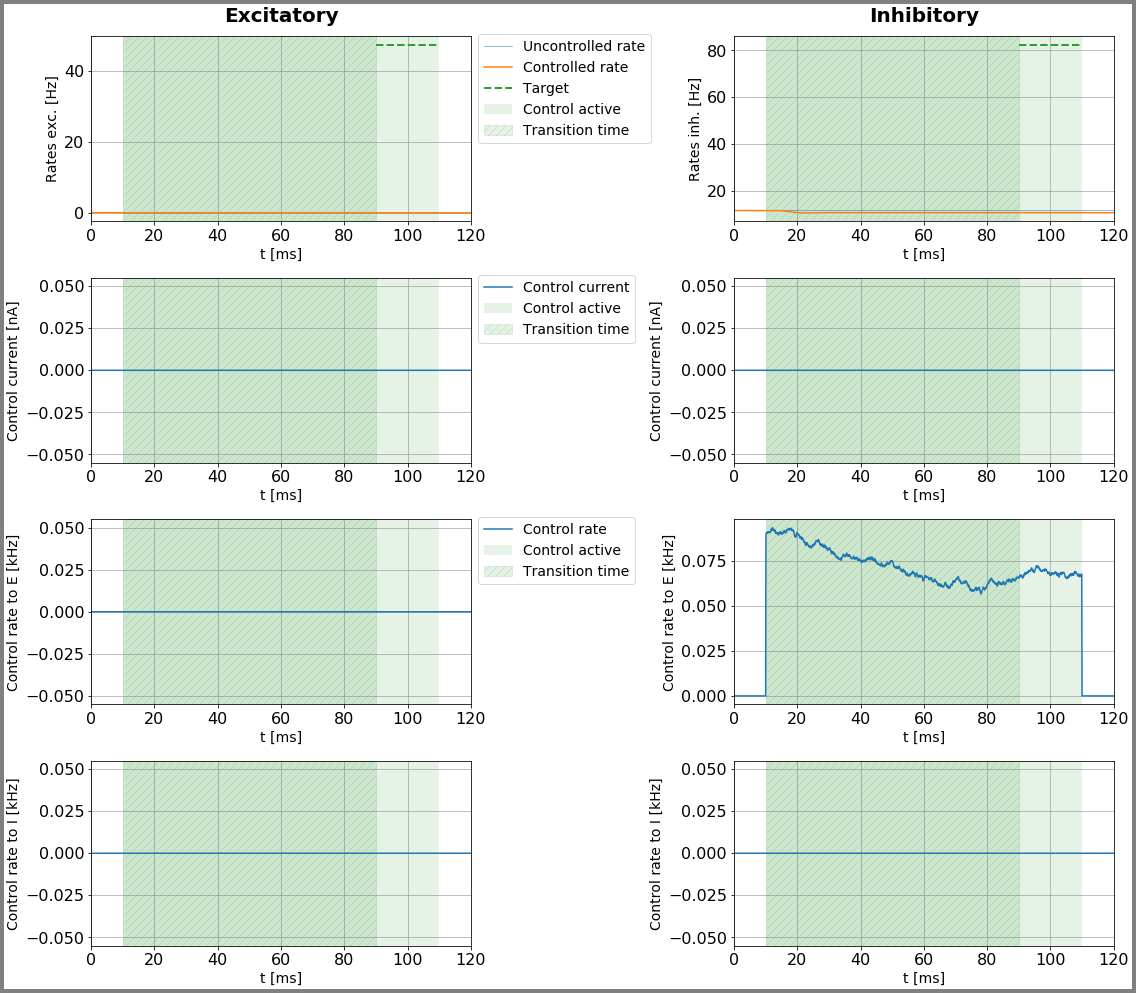

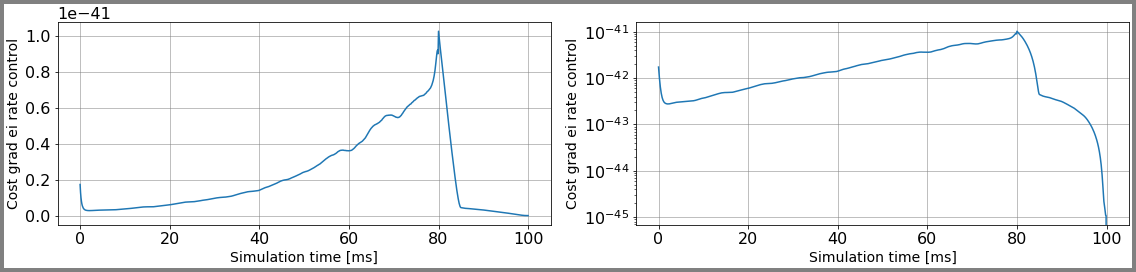

In [13]:
c_ = 4
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [3] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22671.089357669734
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.34777445878
RUN  3 , total integrated cost =  22492.302010986437
RUN  4 , total integrated cost =  22492.291594605787
RUN  5 , total integrated cost =  22492.291266410546
RUN  6 , total integrated cost =  22492.291263363306


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  22492.291263363302
RUN  8 , total integrated cost =  22492.291263363302
Control only changes marginally.
RUN  8 , total integrated cost =  22492.291263363302
Improved over  8  iterations in  0.28030159999997295  seconds by  0.7886612393680252  percent.
Problem in initial value trasfer:  Vmean_exc -56.29876665805448 -56.298893356885614


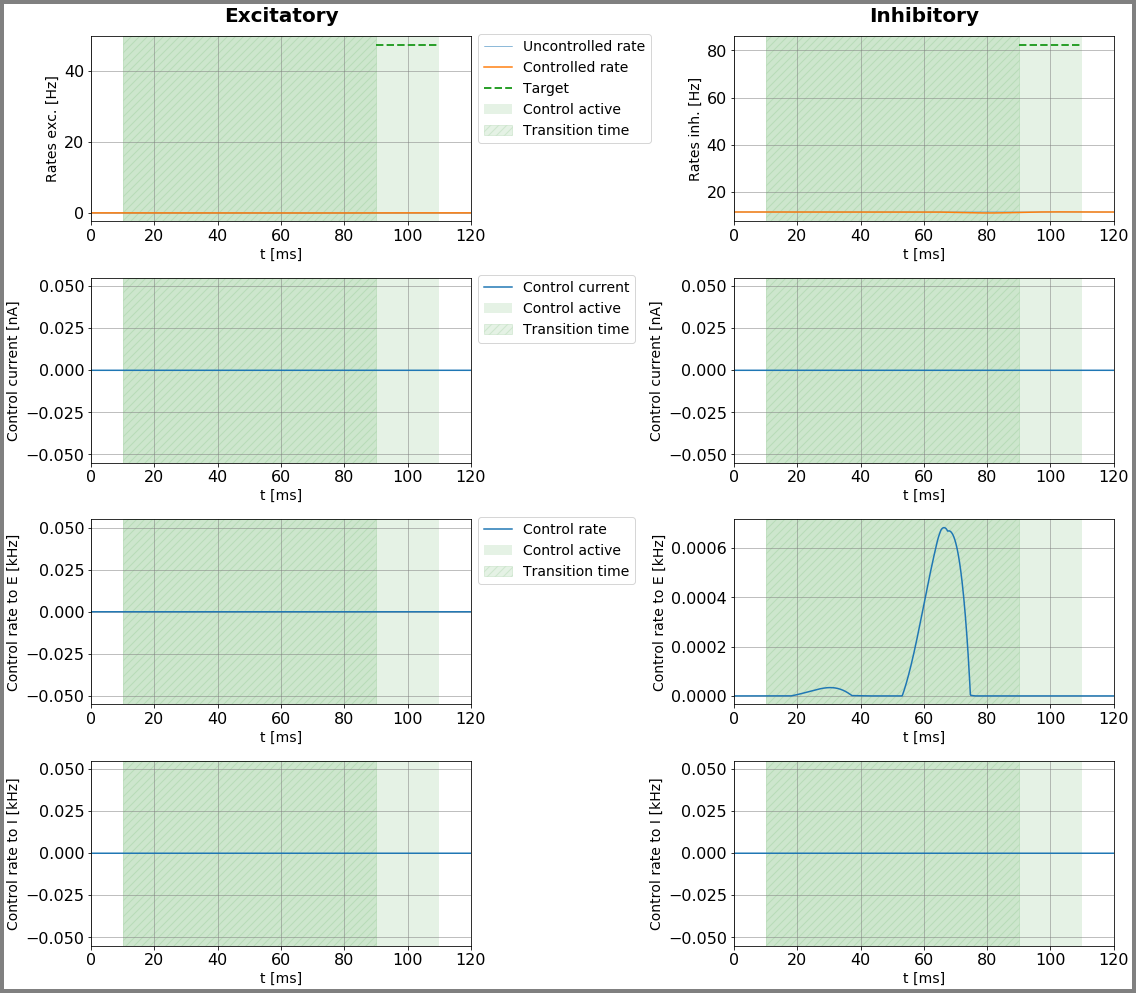

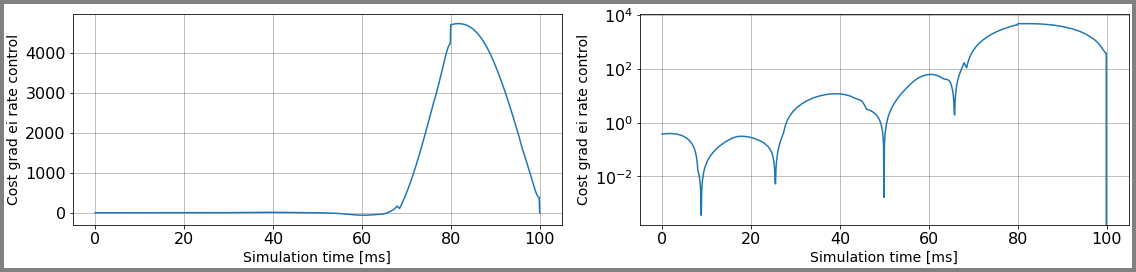

In [14]:
c_ = 4
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 6

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22571.787712787307
Gradient descend method:  None
RUN  1 , total integrated cost =  22571.787712787307
Control only changes marginally.
RUN  1 , total integrated cost =  22571.787712787307
Improved over  1  iterations in  0.01698110000000952  seconds by  0.0  percent.
Problem in initial value trasfer:  sigmai_f 0.5066865976853693 0.5344127091521084
Problem in initial value trasfer:  Vmean_exc -75.19201543557935 -75.19449279776892


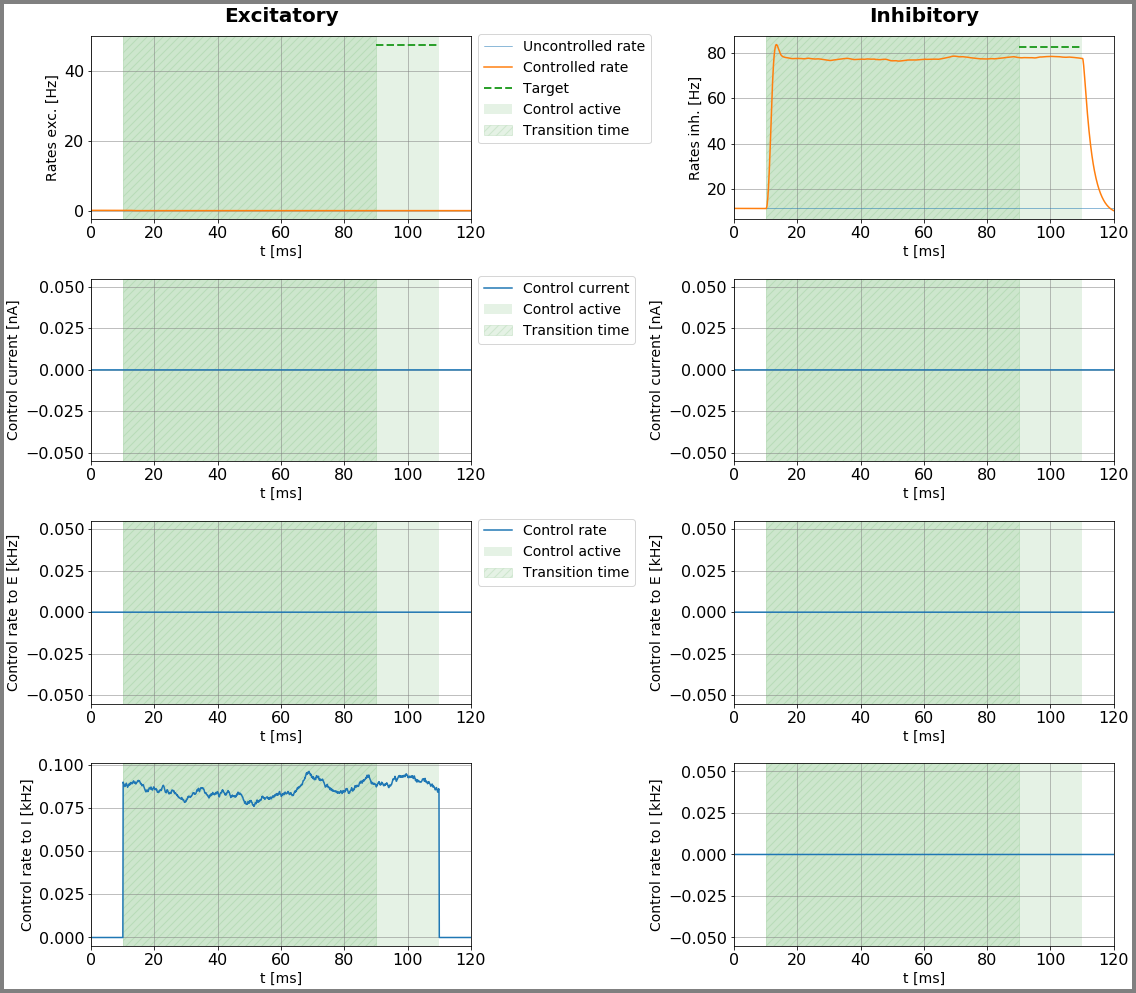

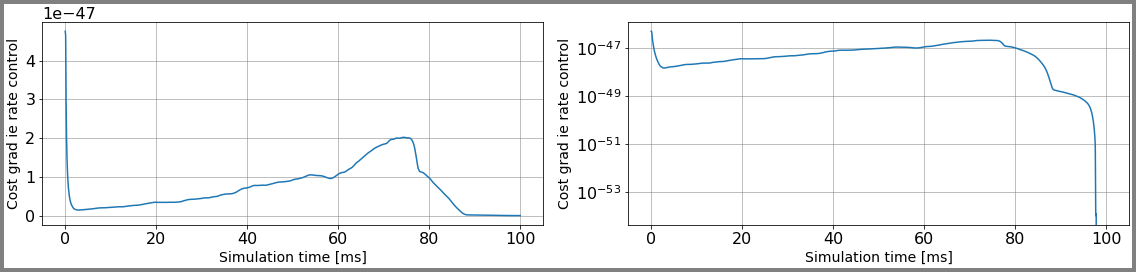

In [15]:
c_ = 5
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [4] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22695.21849934781
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.494361608944
RUN  2 , total integrated cost =  22493.205225769263
RUN  3 , total integrated cost =  22492.184065981408
RUN  4 , total integrated cost =  22492.177371560465
RUN  5 , total integrated cost =  22492.17672661437
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 6 , total integrated cost =  22492.176719237006
RUN  7 , total integrated cost =  22492.176719139563
RUN  8 , total integrated cost =  22492.176719139563
Control only changes marginally.
RUN  8 , total integrated cost =  22492.176719139563
Improved over  8  iterations in  0.2723330999999689  seconds by  0.8946456286115279  percent.
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.382311323526517
Problem in initial value trasfer:  Vmean_exc -56.29824218663594 -56.298369490351355


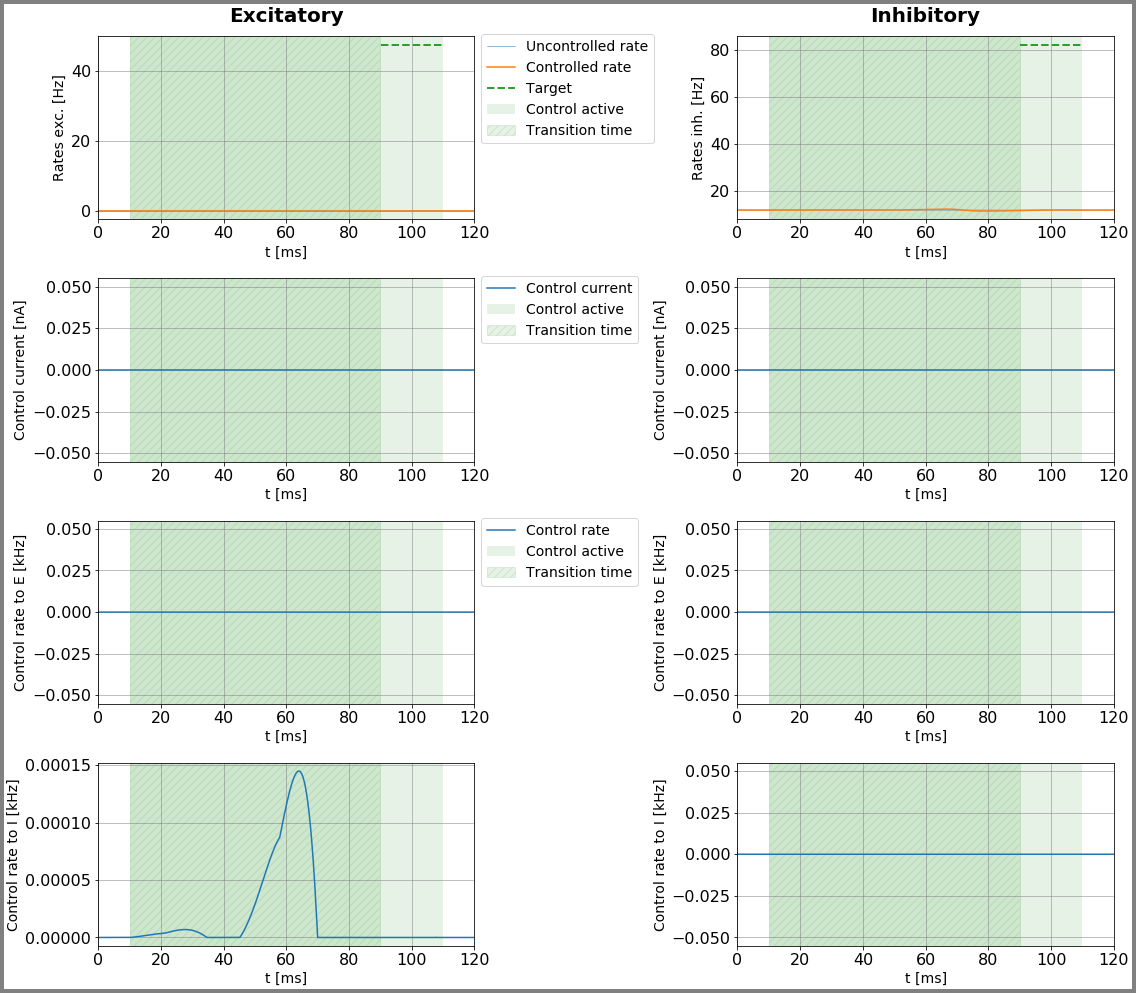

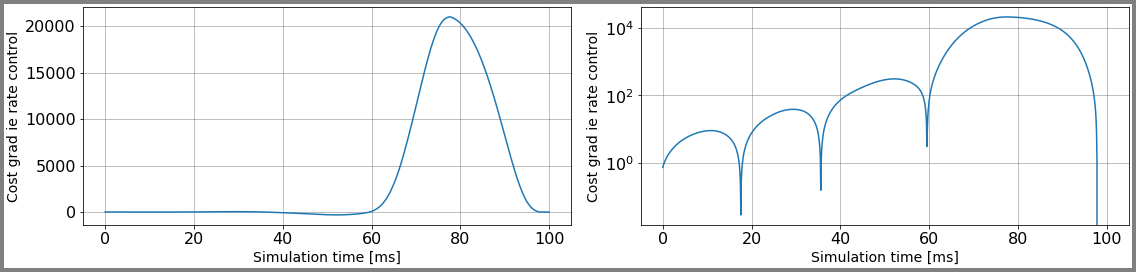

In [16]:
c_ = 5
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 7

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.08359175616454388
Gradient descend method:  None
RUN  1 , total integrated cost =  3.728151704328847e-13
RUN  2 , total integrated cost =  3.117637231736708e-13
RUN  3 , total integrated cost =  2.1408910849297413e-13
RUN  4 , total integrated cost =  1.1464085737628228e-13
RUN  5 , total integrated cost =  3.201271063735759e-14
RUN  6 , total integrated cost =  3.0948374885708866e-14
RUN  7 , total integrated cost =  1.8015851005088135e-14
RUN  8 , total integrated cost =  1.8001547994495295e-14
RUN  9 , total integrated cost =  1.7710087742063765e-14
RUN  10 , total integrated cost =  1.7705157926330942e-14
RUN  11 , total integrated cost =  1.743652272231621e-14
RUN  12 , total integrated cost =  1.7426915208746872e-14
RUN  13 , total integrated cost =  1.7174903510100608e-14
RUN  14 , total integrated cost =  1.717130406425135e-14
RUN  15 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  283 , total integrated cost =  1.2185317532792055e-14
Improved over  283  iterations in  7.880804699999999  seconds by  99.99999999998542  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5236309419822106
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.489136801837844
Problem in initial value trasfer:  sigmai_f 0.5015959128141813 0.501623342544769
Problem in initial value trasfer:  Vmean_exc -56.1745953402893 -56.17460628827935
Problem in initial value trasfer:  tau_inh 0.5110871335496285 0.5110886311563714


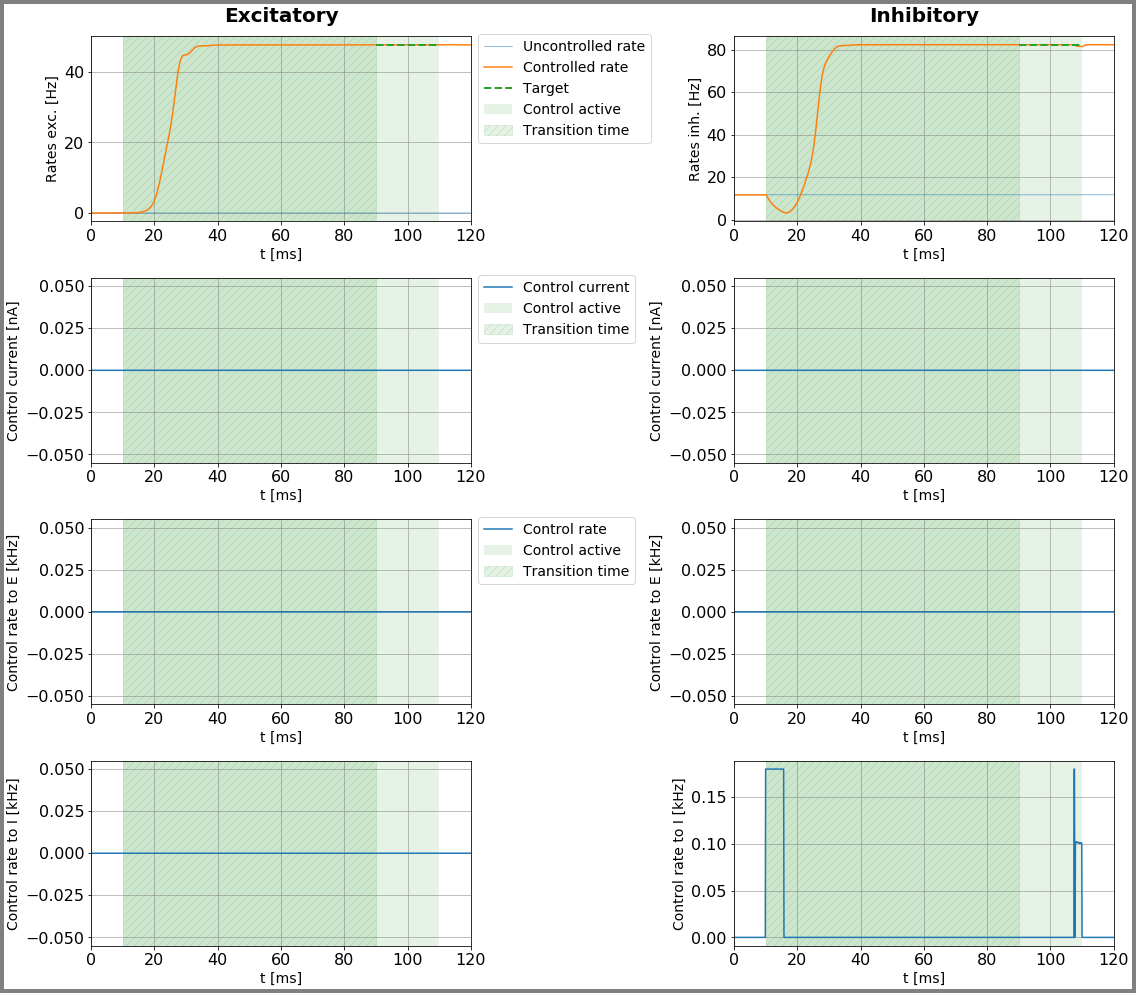

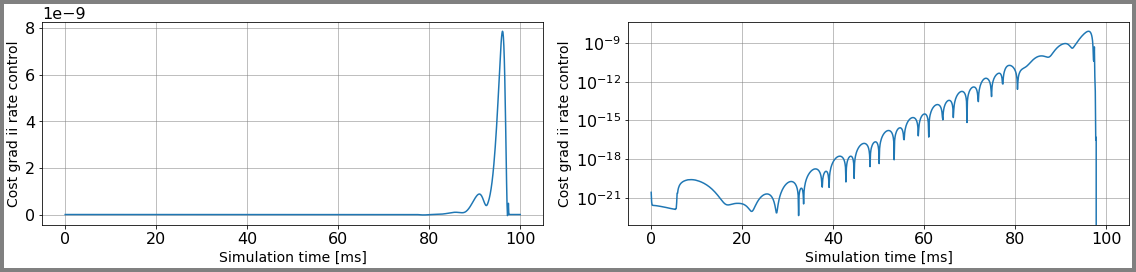

In [17]:
c_ = 6
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  57.270481203712144
Gradient descend method:  None
RUN  1 , total integrated cost =  7.391020990146343
RUN  2 , total integrated cost =  5.480611019224111
RUN  3 , total integrated cost =  5.333205423711516
RUN  4 , total integrated cost =  2.940860967501638
RUN  5 , total integrated cost =  2.638373005266676
RUN  6 , total integrated cost =  2.6255767946229356
RUN  7 , total integrated cost =  2.6249764488759086
RUN  8 , total integrated cost =  2.624065671287693
RUN  9 , total integrated cost =  2.623457602861686
RUN  10 , total integrated cost =  2.622514365934853
RUN  11 , total integrated cost =  2.6218714623844717
RUN  12 , total integrated cost =  2.620917027884632
RUN  13 , total integrated cost =  2.6202899315680663
RUN  14 , total integrated cost =  2.619320209877813
RUN  15 , total integrated cost =  2.6186204262743322
RUN  16 , total integrate

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  2.32747825867248
RUN  1000 , total integrated cost =  2.32747825867248
Improved over  1000  iterations in  25.281016999999963  seconds by  95.93598969354981  percent.
Problem in initial value trasfer:  sigmai_f 0.5540255416344939 0.5520982170032206
Problem in initial value trasfer:  tau_inh 6.38231131322099 6.389085128234658
Problem in initial value trasfer:  Vmean_exc -56.17459098264512 -56.17459099415865


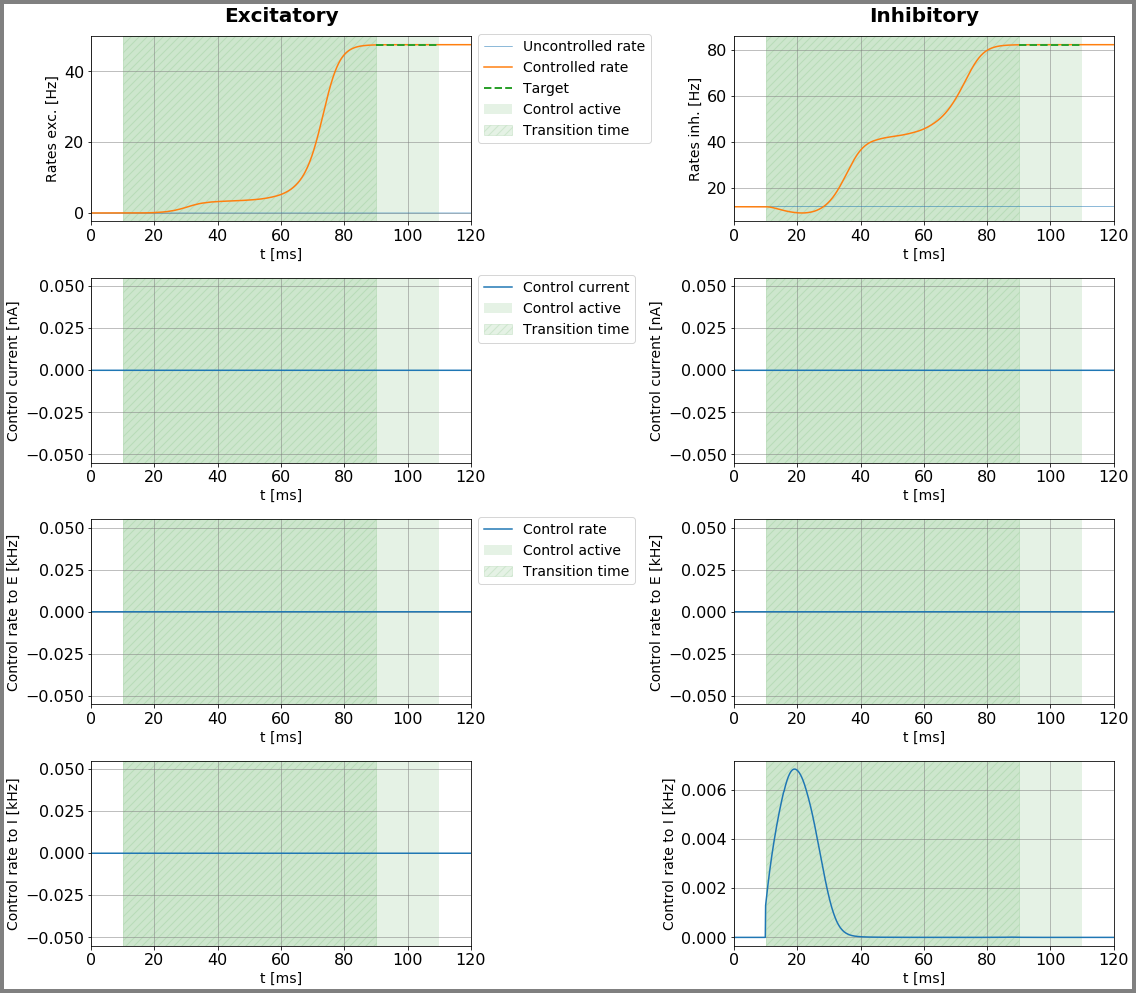

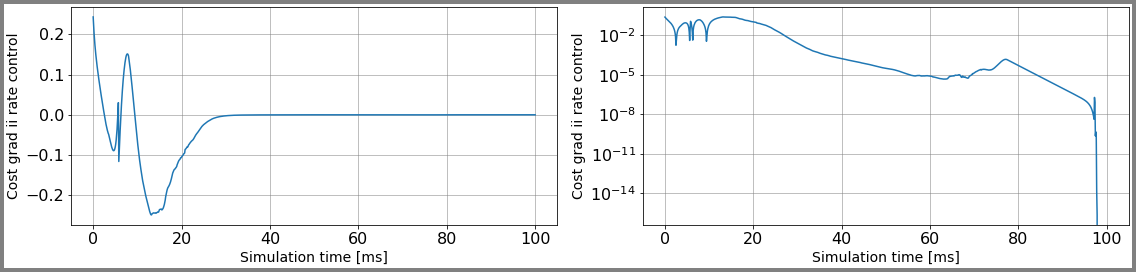

In [18]:
c_ = 6
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

## 8

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.859141189040086
Gradient descend method:  None
RUN  1 , total integrated cost =  0.08713306777378875
RUN  2 , total integrated cost =  0.01974111361360886
RUN  3 , total integrated cost =  0.008555442298027266
RUN  4 , total integrated cost =  0.004894148658028816
RUN  5 , total integrated cost =  0.0032144091242732216
RUN  6 , total integrated cost =  0.0022818135574437883
RUN  7 , total integrated cost =  0.0017399646458378828
RUN  8 , total integrated cost =  0.0013739073773613168
RUN  9 , total integrated cost =  0.001119780263514451
RUN  10 , total integrated cost =  0.0009334207081907153
RUN  11 , total integrated cost =  0.0007910599704915812
RUN  12 , total integrated cost =  0.0006786139020837937
RUN  13 , total integrated cost =  0.0005892316565242729
RUN  14 , total integrated cost =  0.0005182556368550867
RUN  15 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  5.7041997648452745e-12
RUN  1000 , total integrated cost =  5.7041997648452745e-12
Improved over  1000  iterations in  56.10113919999998  seconds by  99.99999999994215  percent.
Problem in initial value trasfer:  sigmae_f 0.5007853069040861 0.5013357173793753
Problem in initial value trasfer:  sigmai_f 0.5003512968354773 0.5006065531027404
Problem in initial value trasfer:  Vmean_exc -56.17356370990122 -56.17280975826457


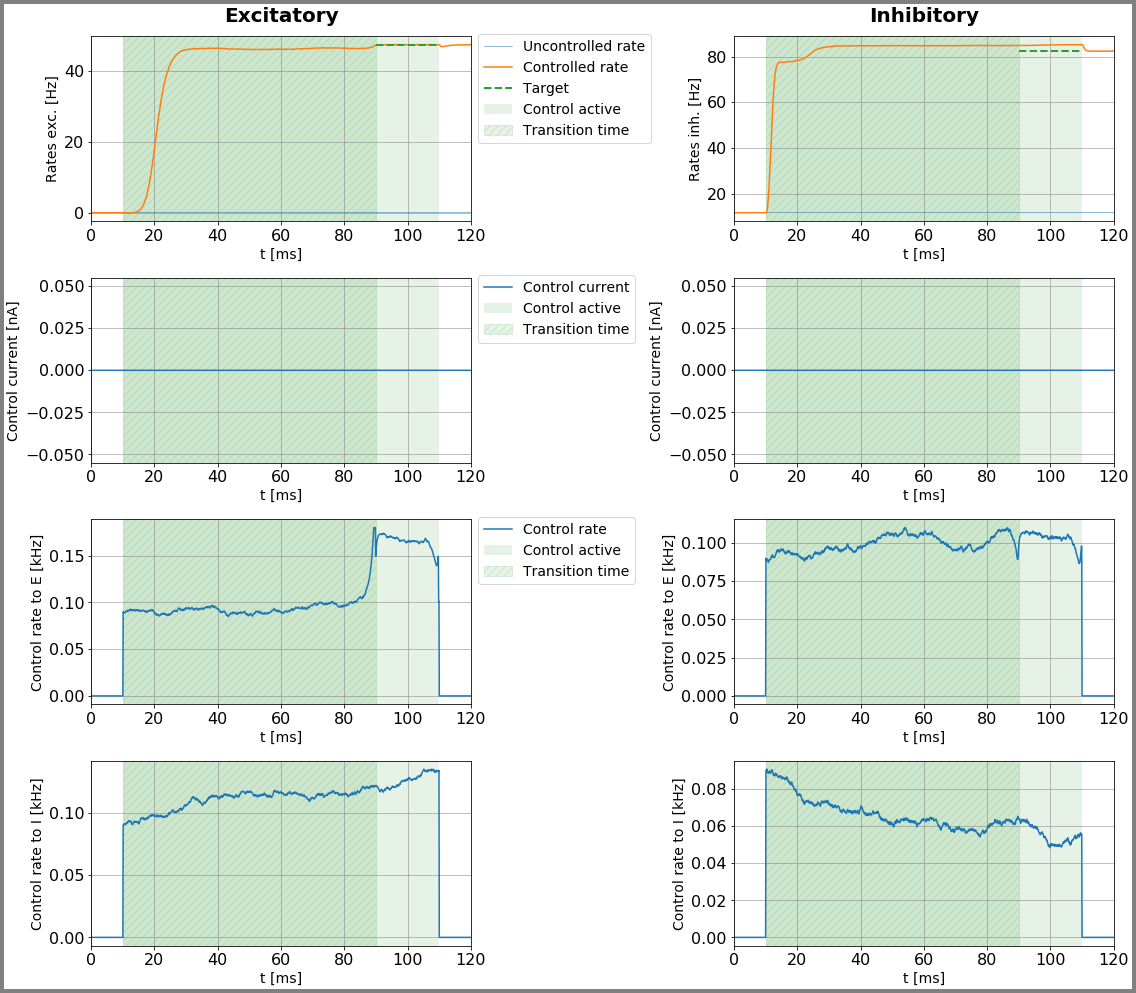

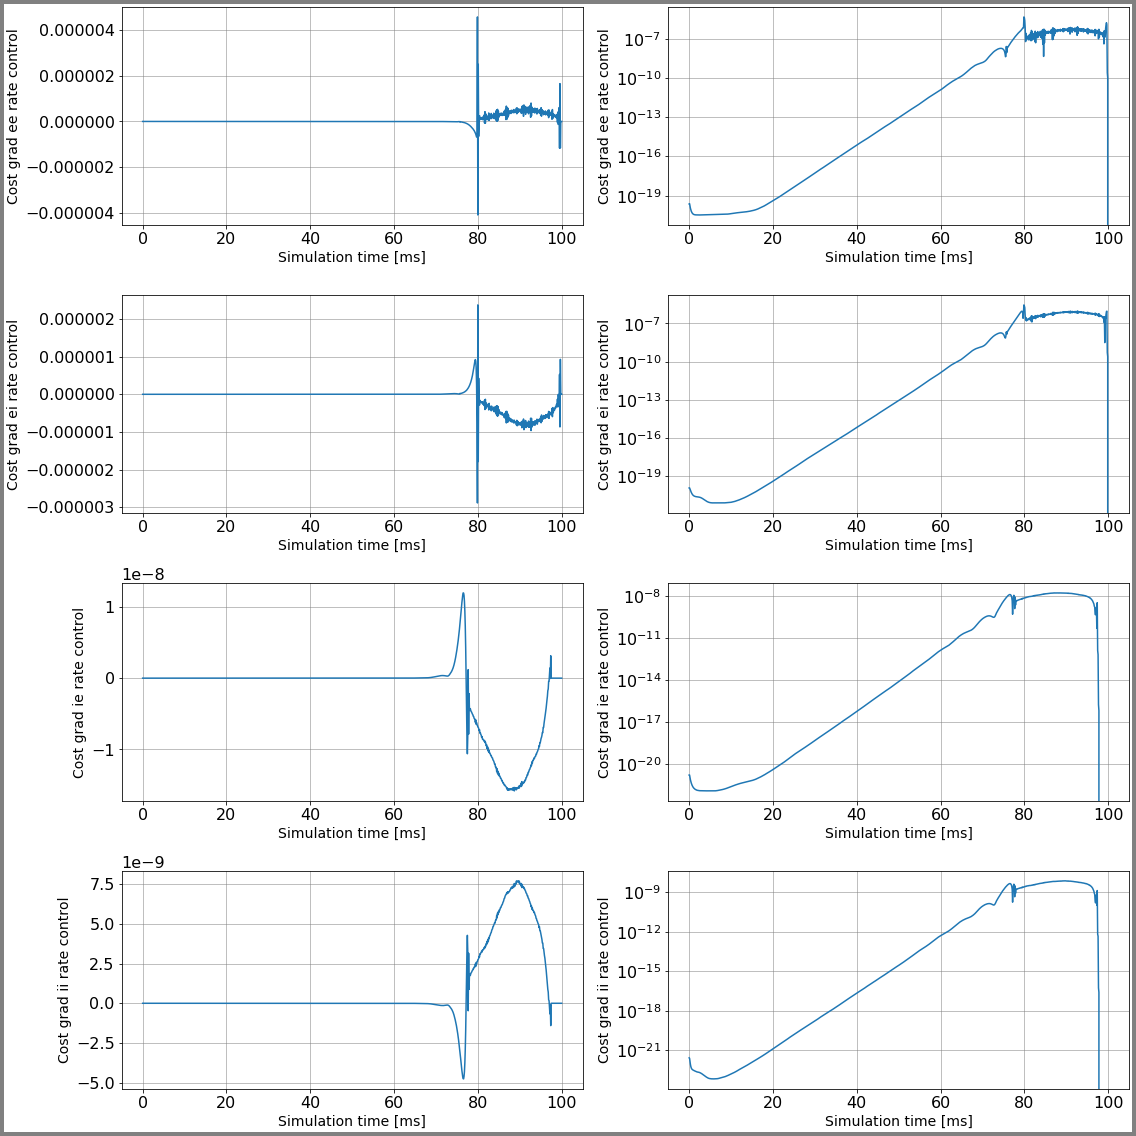

In [19]:
c_ = 7
case = sheet + str(c_) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla[c_], bestStatea[c_], costa[c_], runtimea[c_], grada[c_], phia[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControla[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(grada[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

set cost params
control input:  [2, 3, 4, 5] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  591.0156984911157
Gradient descend method:  None
RUN  1 , total integrated cost =  39.39557050800455
RUN  2 , total integrated cost =  24.185847825767514
RUN  3 , total integrated cost =  13.708435659442348
RUN  4 , total integrated cost =  3.086970622655386
RUN  5 , total integrated cost =  1.1583830094335017
RUN  6 , total integrated cost =  1.131965225601054
RUN  7 , total integrated cost =  0.875987267413831
RUN  8 , total integrated cost =  0.6433022422056484
RUN  9 , total integrated cost =  0.6392285769249955
RUN  10 , total integrated cost =  0.6349665379654567
RUN  11 , total integrated cost =  0.6332648144301696
RUN  12 , total integrated cost =  0.6330131976694464
RUN  13 , total integrated cost =  0.63260802158993
RUN  14 , total integrated cost =  0.6324716816724725
RUN  15 , total integrated cost =  0.6322641837050115
RUN  16 , tot

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  0.6099441146729734
RUN  1000 , total integrated cost =  0.6099441146729734
Improved over  1000  iterations in  97.03195629999993  seconds by  99.89679730737606  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7145064966048752
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.104470199492273


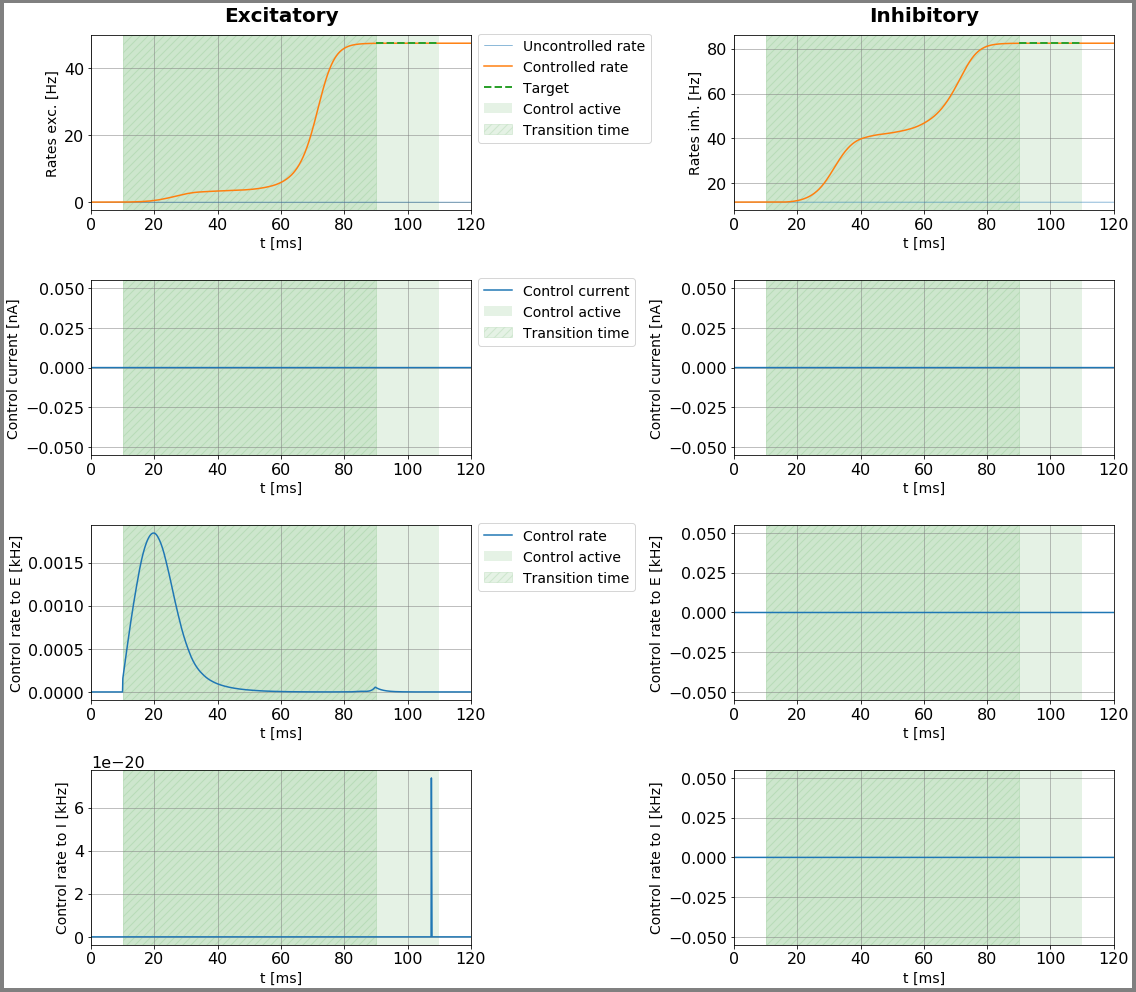

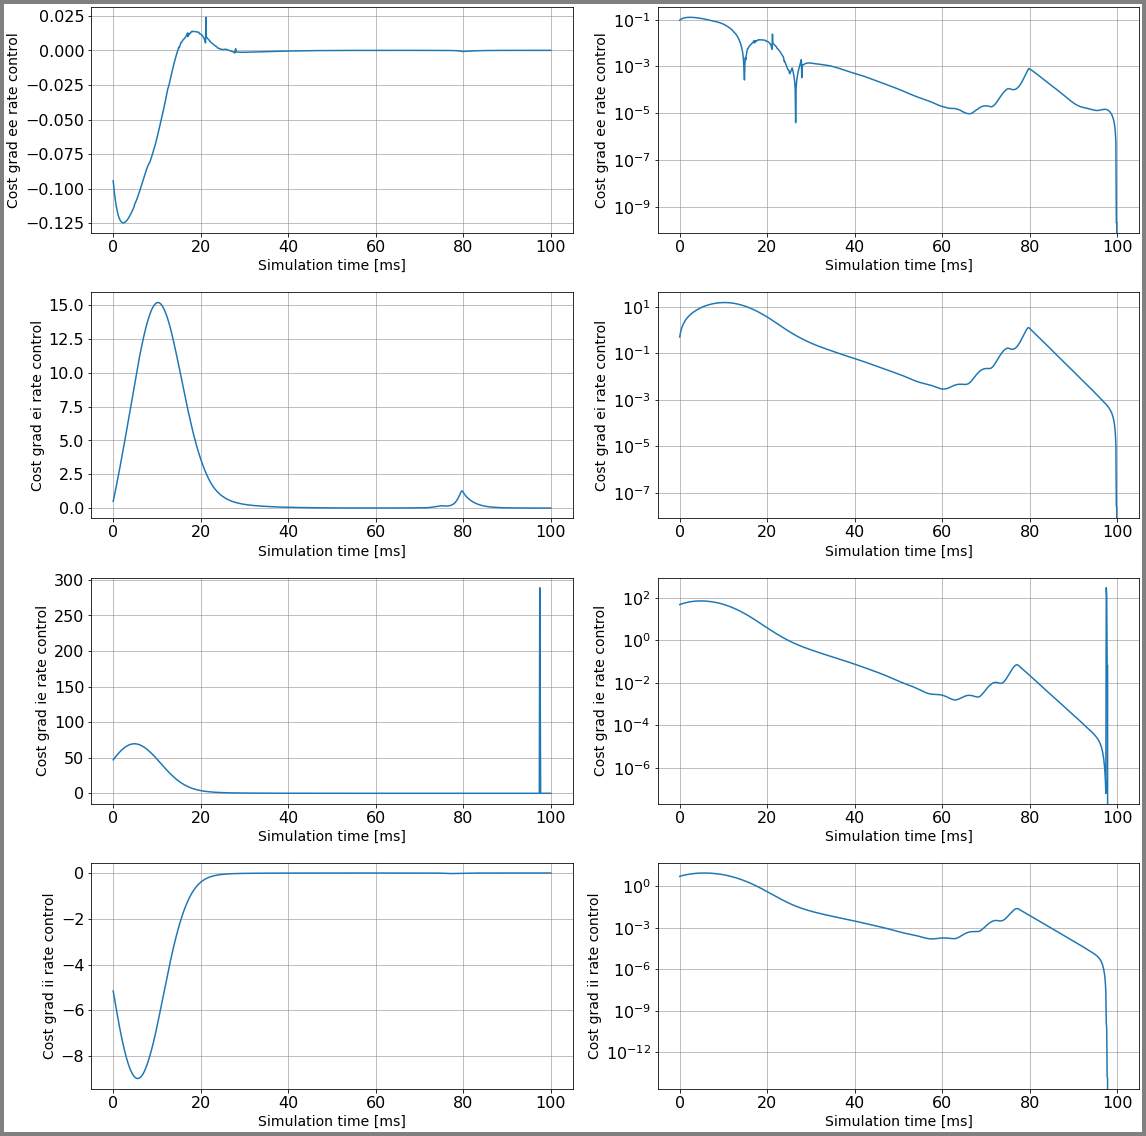

In [20]:
c_ = 7
case = sheet + str(c_) + "b"
cost.setParams(1.0, 1e2, 1e2)
cntrl_vars = c_var[c_]
prec_vars = p_var[c_]

trans_time = trans_time_array[c_]
max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)
aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0 = setrandomcontrol(control0, max_cntrl, min_cntrl, cntrl_vars)
#control1 = bestControla[c_][:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControlb[c_], bestStateb[c_], costb[c_], runtimeb[c_], gradb[c_], phib[c_] = aln.A1(
    control0, target, c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
    startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
    t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars,
    prec_variables_ = prec_vars, transition_time_ = trans_time)

plotFunc.plot_control(aln, bestControlb[c_], dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )
plotFunc.plot_gradient(gradb[c_], dur, aln.params.dt, path, plot_vars = cntrl_vars)

In [ ]:
print("cost a")
for i in range(len(costa)):
    j = int(len(costa[i]) - 1)
    while costa[i][j] == 0.:
        j = int(j-1)
    print(costa[i][j])

print("cost b")
for i in range(len(costb)):
    j = int(len(costb[i]) - 1)
    while costb[i][j] == 0.:
        j = int(j-1)
    print(costb[i][j])